# Regional Consumer Behaviour EDA

**IT5006 Group 9 · Milestone 1 · Olist Brazilian E-Commerce (2016–2018)**

**Candidate question:** Regression: Regional Monthly Sales Forecast
* Question: What will next month's GMV be in each state?
* Target: Continuous (log item GMV per state group per month)
* Stakeholder: Regional demand planning / seller operations at Olist
* Features: Lagged state GMV and order counts, new-customer count, time trend, Black Friday dummy, state fixed effect, state behaviour profile (AOV, freight ratio, category mix)

This notebook explores the *regional demand* candidate problem: how purchasing behaviour differs
across Brazilian states, and whether state × month GMV is forecastable. It builds on the foundation
notebook `00_dataset_overview_eda.ipynb` and does **not** repeat it — dataset overview, table joins,
temporal patterns, entity distributions and the order-level correlation matrix all live in `00`.

**Scope.** Descriptive analysis only. No model is fitted, no value is imputed and no train/test
split is made here; those belong to Phase 2.

| Section | What it covers |
|---|---|
| 1. Setup and loading | read the consolidated table produced by `00` |
| 2. Order-level behaviour frame | one row per order: basket, payment, delivery, review, distance |
| 3. Behaviour profile per state | AOV, instalments, boleto share, freight ratio, late rate, reviews, repeat rate |
| 4. Category mix | category preference index by state vs. the national mix |
| 5. Monthly sales by state | usable window, top-5 persistence, state × month GMV panel, co-movement |
| 6. Leading signals | which within-state features correlate with next month's GMV |
| 7. Key insights | summary of regional patterns and what they imply for forecasting |

**Reproducibility.** The only input is `smartcommerce_consolidated_v2.csv`, written by `00` next to
the raw CSV folder. Run `00` first; nothing here touches the raw archive directly.

## 1. Setup and loading

The loader mirrors `00`: it locates `data/Olist_CSV/` (or `OLIST_CSV_DIR`, or the Colab mount) and
reads the consolidated table from the folder above it, which is where `00` writes it. The table is
at **order-item grain** (one row per line item, 112,650 rows); column meanings and the leakage
classification are documented in `00` Section 6.


In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", "{:,.2f}".format)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__)

pandas 3.0.5 | numpy 2.5.2 | seaborn 0.13.2


In [2]:
def find_csv_dir():
    """Locate the folder holding the nine Olist CSVs, trying the usual places in order (same as 00)."""
    candidates = []
    if os.environ.get("OLIST_CSV_DIR"):
        candidates.append(Path(os.environ["OLIST_CSV_DIR"]))
    here = Path.cwd()
    candidates += [
        here / "data" / "Olist_CSV",                # run from the repository root
        here.parent / "data" / "Olist_CSV",         # run from notebooks/
        here / "data",
        here.parent / "data",
        Path("/content/drive/MyDrive/IT5006_Olist_Project/Olist_CSV"),   # Colab
        Path.home() / "Desktop" / "it5006" / "IT5006_Project-Data" / "Olist_CSV",
    ]
    for c in candidates:
        if (c / "olist_orders_dataset.csv").exists():
            return c
    raise FileNotFoundError(
        "Could not find the Olist CSVs. Unpack the course archive into data/Olist_CSV/ at the "
        "repository root, or set OLIST_CSV_DIR to the folder that holds them. Tried:\n  "
        + "\n  ".join(str(c) for c in candidates))


CSV_DIR = find_csv_dir()
DATA_DIR = CSV_DIR.parent if CSV_DIR.name == "Olist_CSV" else CSV_DIR
CONS_PATH = DATA_DIR / "smartcommerce_consolidated_v2.csv"
if not CONS_PATH.exists():
    raise FileNotFoundError(f"{CONS_PATH} not found — run 00_dataset_overview_eda.ipynb first.")

DATE_COLS = ["order_purchase_timestamp", "order_delivered_customer_date",
             "order_estimated_delivery_date", "shipping_limit_date",
             "review_creation_date", "review_answer_timestamp"]
consolidated = pd.read_csv(CONS_PATH, parse_dates=DATE_COLS)
consolidated["year_month"] = consolidated.order_purchase_timestamp.dt.to_period("M")

assert not consolidated.duplicated(["order_id", "order_item_id"]).any(), "grain is not one row per line item"
print(f"Read {CONS_PATH.name}: {len(consolidated):,} line items, "
      f"{consolidated.order_id.nunique():,} orders, {consolidated.shape[1]} columns")

Read smartcommerce_consolidated_v2.csv: 112,650 line items, 98,666 orders, 45 columns


## 2. Order-level behaviour frame

Every question in this notebook is about an order or a customer, not a line item, so the first step
is to collapse to one row per order. The aggregation follows `to_order_level` in `00` Section 6
(basket = sum of prices, freight summed, `n_items` = row count, distance = the farthest item because
that is the binding delivery leg) and adds the behaviour flags this notebook needs:

- `credit` / `boleto` — whether the order's **main** payment type (largest payment row, as defined in
  `00`) is credit card or boleto.
- `cross_state` — at least one item shipped from a state other than the customer's (`not all_same_state`).
- `is_late` — delivered after the promised date; `NaN` for undelivered orders so that late rates are
  computed over delivered orders only.


In [3]:
order_level = (consolidated.groupby("order_id").agg(
    customer_state=("customer_state", "first"),
    customer_unique_id=("customer_unique_id", "first"),
    order_status=("order_status", "first"),
    purchase_ts=("order_purchase_timestamp", "first"),
    delivered_ts=("order_delivered_customer_date", "first"),
    estimated_ts=("order_estimated_delivery_date", "first"),
    n_items=("order_item_id", "size"),
    n_categories=("product_category_name_english", "nunique"),
    basket_value=("price", "sum"),
    freight=("freight_value", "sum"),
    total_weight_g=("product_weight_g", "sum"),
    max_distance_km=("distance_km", "max"),
    all_same_state=("same_state", "all"),
    payment_total=("payment_total", "first"),
    payment_max_installments=("payment_max_installments", "first"),
    n_payment_methods=("n_payment_methods", "first"),
    main_payment_type=("main_payment_type", "first"),
    review_score=("review_score", "first"),
).reset_index())

order_level["cross_state"]   = ~order_level.all_same_state
order_level["credit"]        = order_level.main_payment_type == "credit_card"
order_level["boleto"]        = order_level.main_payment_type == "boleto"
order_level["delivery_days"] = (order_level.delivered_ts - order_level.purchase_ts).dt.days
order_level["is_late"]       = np.where(order_level.delivered_ts.notna(),
                                        order_level.delivered_ts > order_level.estimated_ts, np.nan)
order_level["freight_ratio"] = order_level.freight / order_level.basket_value
order_level["purchase_hour"] = order_level.purchase_ts.dt.hour
order_level["is_weekend"]    = order_level.purchase_ts.dt.dayofweek >= 5
order_level["year_month"]    = order_level.purchase_ts.dt.to_period("M")

assert len(order_level) == consolidated.order_id.nunique()
print("order_level:", order_level.shape)
print(f"Orders without a shipping distance (no zip coordinates): {order_level.max_distance_km.isna().mean():.2%}")
print(f"Median order shipping distance: {order_level.max_distance_km.median():.0f} km  "
      f"(SP customers: {order_level.loc[order_level.customer_state == 'SP', 'max_distance_km'].median():.0f} km)")
order_level.head(3)

order_level: (98666, 28)
Orders without a shipping distance (no zip coordinates): 0.50%
Median order shipping distance: 435 km  (SP customers: 165 km)


,order_id,customer_state,customer_unique_id,order_status,purchase_ts,delivered_ts,estimated_ts,n_items,n_categories,basket_value,freight,total_weight_g,max_distance_km,all_same_state,payment_total,payment_max_installments,n_payment_methods,main_payment_type,review_score,cross_state,credit,boleto,delivery_days,is_late,freight_ratio,purchase_hour,is_weekend,year_month
0,00010242fe8c5a6d1ba2dd792cb16214,RJ,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,1,1,58.90,13.29,650.00,301.50,False,72.19,2.00,1.00,credit_card,5.00,True,True,False,7.00,0.00,0.23,8,False,2017-09
1,00018f77f2f0320c557190d7a144bdd3,SP,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,1,1,239.90,19.93,"30,000.00",585.60,True,259.83,3.00,1.00,credit_card,4.00,False,True,False,16.00,0.00,0.08,10,False,2017-04
2,000229ec398224ef6ca0657da4fc703e,MG,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,1,1,199.00,17.87,"3,050.00",312.30,True,216.87,5.00,1.00,credit_card,5.00,False,True,False,7.00,0.00,0.09,14,True,2018-01


## 3. One behaviour profile per state

Repeat rate has to be computed per person *before* aggregating to state, otherwise a state's value
is the share of order rows from repeaters rather than the share of people who repeat.


In [4]:
per_person = order_level.groupby(["customer_state", "customer_unique_id"]).order_id.count()
repeat_share = per_person.groupby("customer_state").apply(lambda s: (s > 1).mean())

state_beh = (order_level.groupby("customer_state")
             .agg(orders=("order_id", "size"),
                  aov=("payment_total", "mean"),            # order grain -> true average order value
                  median_basket=("basket_value", "median"),
                  items_per_order=("n_items", "mean"),
                  avg_installments=("payment_max_installments", "mean"),
                  credit_share=("credit", "mean"),
                  boleto_share=("boleto", "mean"),
                  weekend_share=("is_weekend", "mean"),
                  cross_state_share=("cross_state", "mean"),
                  median_dist_km=("max_distance_km", "median"),
                  median_delivery_days=("delivery_days", "median"),
                  late_rate=("is_late", "mean"),            # NaN-safe: undelivered excluded
                  review_mean=("review_score", "mean")))
state_beh["freight_ratio"] = order_level.groupby("customer_state").apply(
    lambda g: g.freight.sum() / g.basket_value.sum())
state_beh["repeat_customer_share"] = repeat_share
state_beh = state_beh.sort_values("orders", ascending=False)
state_beh.round(3)

,orders,aov,median_basket,items_per_order,avg_installments,credit_share,boleto_share,weekend_share,cross_state_share,median_dist_km,median_delivery_days,late_rate,review_mean,freight_ratio,repeat_customer_share
customer_state,,,,,,,,,,,,,,,
SP,41375,143.14,79.80,1.15,2.69,0.75,0.20,0.23,0.24,164.90,7.00,0.06,4.20,0.14,0.03
RJ,12762,166.90,89.99,1.14,3.06,0.78,0.17,0.24,0.92,395.65,12.00,0.14,3.89,0.17,0.03
MG,11544,160.82,89.90,1.14,3.06,0.76,0.20,0.23,0.87,490.80,10.00,0.06,4.16,0.17,0.03
RS,5432,163.14,89.00,1.15,3.04,0.71,0.25,0.23,0.95,856.40,13.00,0.07,4.15,0.18,0.03
PR,4998,160.29,84.99,1.15,2.94,0.73,0.22,0.23,0.85,426.60,10.00,0.05,4.20,0.17,0.03
SC,3612,168.96,89.90,1.16,2.93,0.73,0.23,0.22,0.93,530.30,13.00,0.10,4.09,0.17,0.03
BA,3358,182.14,94.90,1.13,3.34,0.76,0.18,0.24,0.98,"1,425.30",16.00,0.14,3.88,0.20,0.03
DF,2125,166.24,87.99,1.13,2.77,0.78,0.18,0.22,0.98,867.20,11.00,0.07,4.08,0.17,0.03
ES,2025,160.41,89.00,1.11,3.06,0.76,0.20,0.23,1.00,762.45,13.00,0.12,4.05,0.18,0.03


**Observation.** Average order value is the total paid (`payment_total`), so it includes freight
and any financing; it equals `price + freight_value` for 99.7% of orders (reconciliation in `00`).

Volumes are wildly uneven: \
SP alone is around 42% of orders while  \
ten states have fewer than 500 (state_beh.orders < 500). 
So the charts below merge the small states (['PI','RN','AL','SE','TO','RO','AM','AC','AP','RR']) into one `N-small` group.


States with <500 orders (merged into 'N-small' for charts): ['PI', 'RN', 'AL', 'SE', 'TO', 'RO', 'AM', 'AC', 'AP', 'RR']


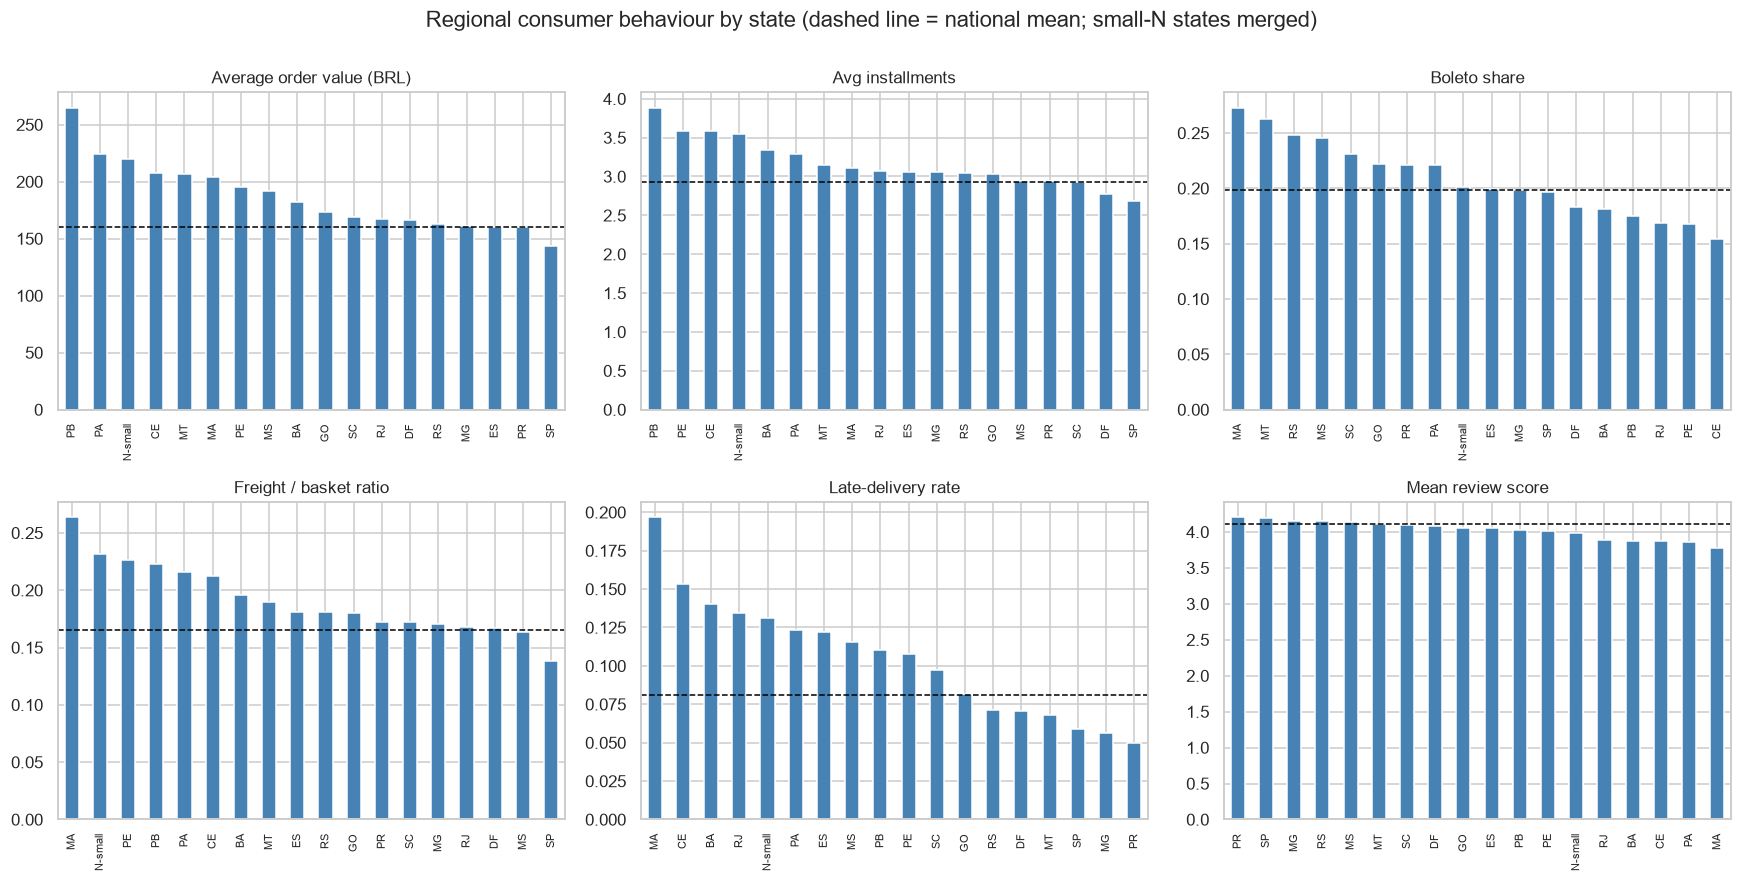

,orders,aov,avg_installments,boleto_share,late_rate,review_mean,repeat,freight_ratio
state_grp,,,,,,,,
SP,41375,143.14,2.69,0.20,0.06,4.20,0.03,0.14
RJ,12762,166.90,3.06,0.17,0.14,3.89,0.03,0.17
MG,11544,160.82,3.06,0.20,0.06,4.16,0.03,0.17
RS,5432,163.14,3.04,0.25,0.07,4.15,0.03,0.18
PR,4998,160.29,2.94,0.22,0.05,4.20,0.03,0.17
SC,3612,168.96,2.93,0.23,0.10,4.09,0.03,0.17
BA,3358,182.14,3.34,0.18,0.14,3.88,0.03,0.20
N-small,2599,220.16,3.55,0.20,0.13,3.98,0.03,0.23
DF,2125,166.24,2.77,0.18,0.07,4.08,0.03,0.17


In [5]:
SMALL = state_beh.index[state_beh.orders < 500].tolist()
print("States with <500 orders (merged into 'N-small' for charts):", SMALL)
order_level["state_grp"] = order_level.customer_state.where(~order_level.customer_state.isin(SMALL), "N-small")

grp = (order_level.groupby("state_grp")
       .agg(orders=("order_id", "size"), aov=("payment_total", "mean"),
            avg_installments=("payment_max_installments", "mean"), boleto_share=("boleto", "mean"),
            freight=("freight", "sum"), basket=("basket_value", "sum"),
            late_rate=("is_late", "mean"), review_mean=("review_score", "mean"),
            repeat=("customer_unique_id", lambda s: (s.value_counts() > 1).mean())))
grp["freight_ratio"] = grp.freight / grp.basket
grp = grp.drop(columns=["freight", "basket"]).sort_values("orders", ascending=False)

METRICS = ["aov", "avg_installments", "boleto_share", "freight_ratio", "late_rate", "review_mean"]
TITLES  = ["Average order value (BRL)", "Avg installments", "Boleto share",
           "Freight / basket ratio", "Late-delivery rate", "Mean review score"]
METRIC_COL = {"aov": "payment_total", "avg_installments": "payment_max_installments",
              "boleto_share": "boleto", "freight_ratio": "freight_ratio",
              "late_rate": "is_late", "review_mean": "review_score"}
NATIONAL = {m: (order_level.freight.sum() / order_level.basket_value.sum() if m == "freight_ratio"
                else order_level[METRIC_COL[m]].mean()) for m in METRICS}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, m, t in zip(axes.flat, METRICS, TITLES):
    grp[m].sort_values(ascending=False).plot.bar(ax=ax, color="steelblue")
    ax.axhline(NATIONAL[m], ls="--", color="black", lw=1)
    ax.set_title(t, fontsize=11); ax.set_xlabel("")
    ax.tick_params(axis="x", labelsize=7)
fig.suptitle("Regional consumer behaviour by state (dashed line = national mean; small-N states merged)", y=1.00)
plt.tight_layout(); plt.show()
grp.round(3)

### 3.1 Behaviour vs. shipping distance

Is geography itself the driver? Each state is placed by its median customer→seller shipping distance
(from `distance_km` in the consolidated table), first at state level and then at order level with
distance binned, which removes the state-composition effect.


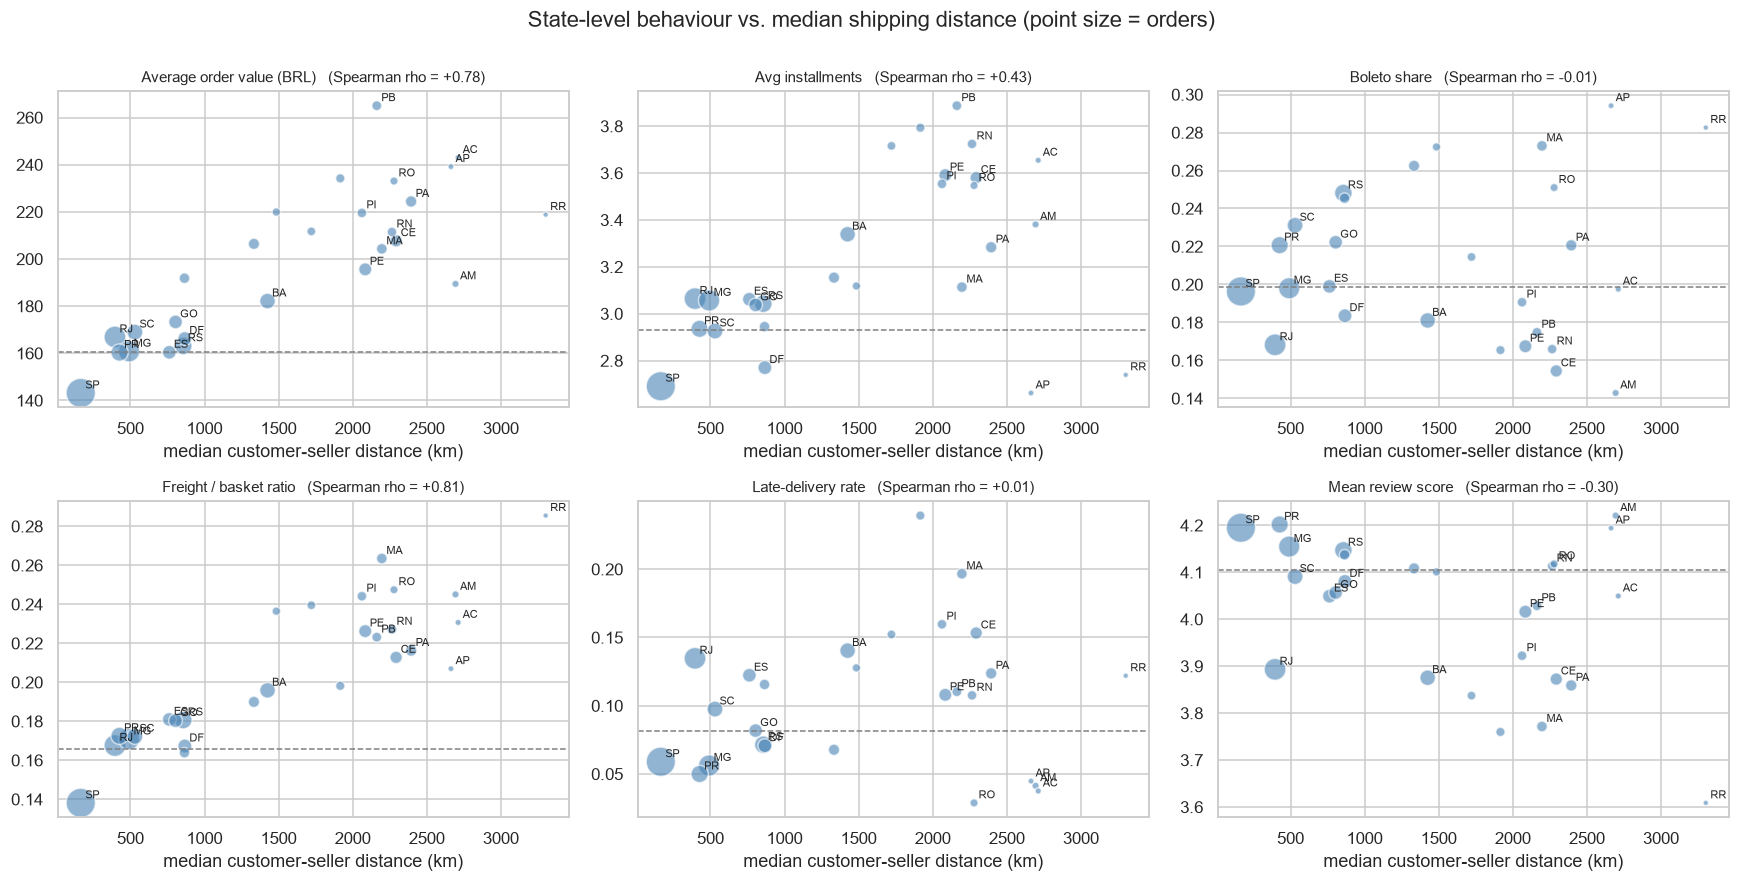

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, m, t in zip(axes.flat, METRICS, TITLES):
    ax.scatter(state_beh.median_dist_km, state_beh[m], s=np.sqrt(state_beh.orders) * 1.8,
               alpha=.6, c="steelblue", edgecolor="white")
    for st, row in state_beh.iterrows():                      # label big markets + far North
        if row.orders > 1500 or row.median_dist_km > 2000:
            ax.annotate(st, (row.median_dist_km, row[m]), fontsize=7, xytext=(3, 3), textcoords="offset points")
    rho = state_beh[["median_dist_km", m]].corr(method="spearman").iloc[0, 1]
    ax.axhline(NATIONAL[m], ls="--", color="gray", lw=1)
    ax.set_title(f"{t}   (Spearman rho = {rho:+.2f})", fontsize=10)
    ax.set_xlabel("median customer-seller distance (km)")
fig.suptitle("State-level behaviour vs. median shipping distance (point size = orders)", y=1.0)
plt.tight_layout(); plt.show()

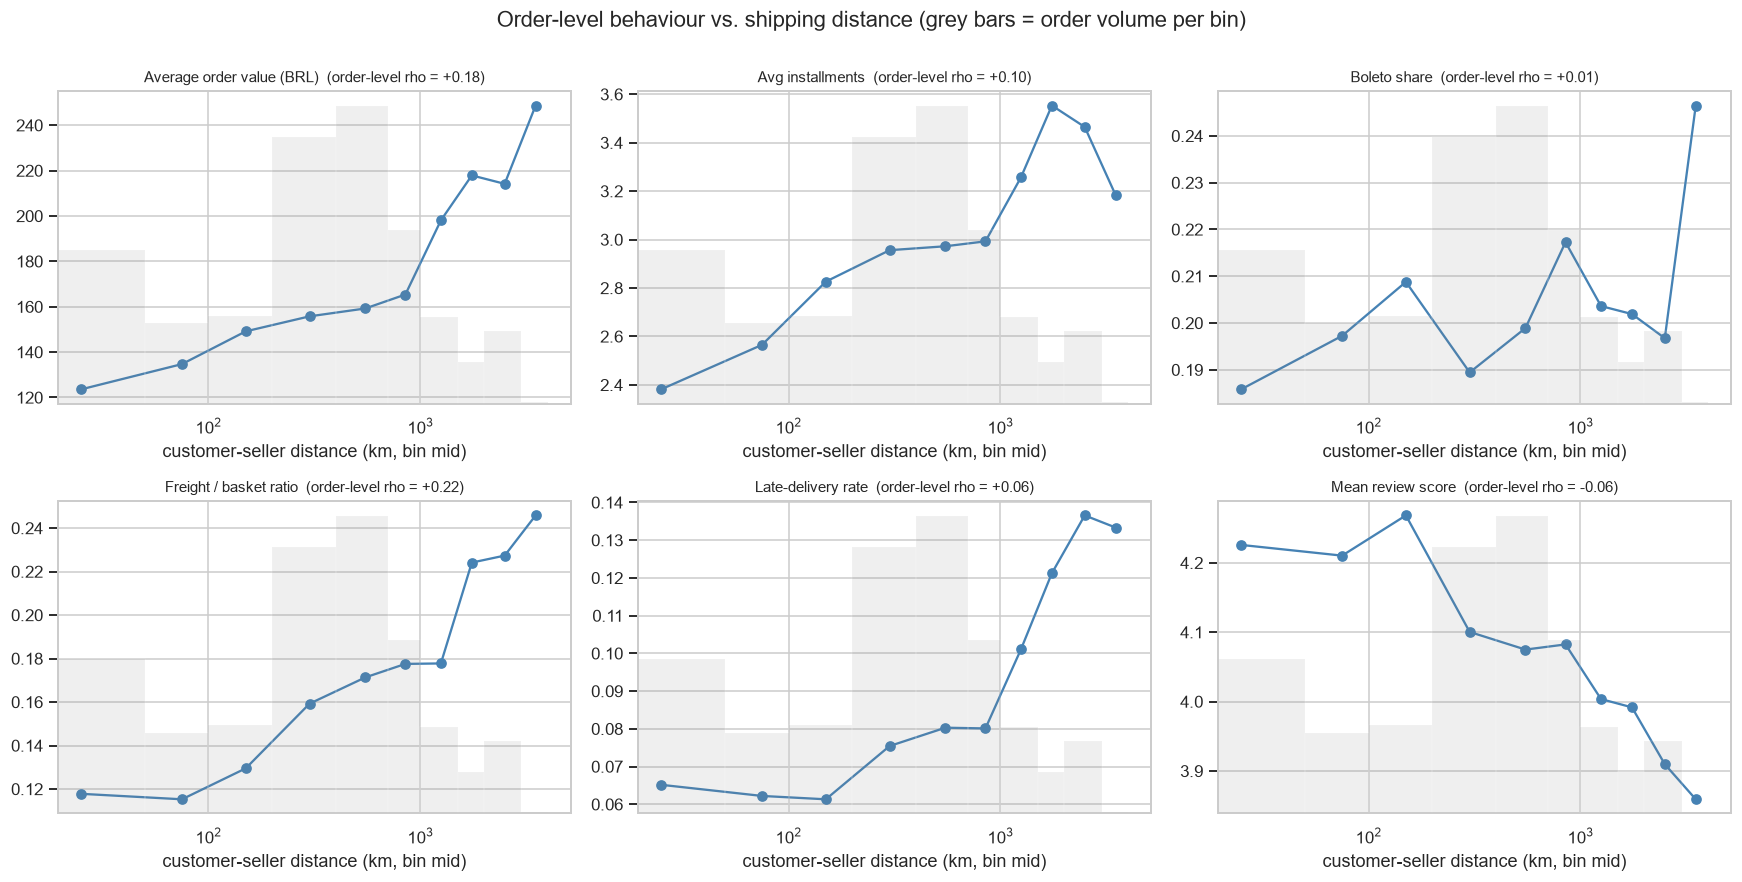

In [7]:
bins = [0, 50, 100, 200, 400, 700, 1000, 1500, 2000, 3000, 4000]
order_level["dist_bin"] = pd.cut(order_level.max_distance_km, bins)

bm = (order_level.groupby("dist_bin", observed=True)
      .agg(n=("order_id", "size"), aov=("payment_total", "mean"),
           avg_installments=("payment_max_installments", "mean"), boleto_share=("boleto", "mean"),
           late_rate=("is_late", "mean"), review_mean=("review_score", "mean"),
           f=("freight", "sum"), b=("basket_value", "sum")))
bm["freight_ratio"] = bm.f / bm.b
x = [iv.mid for iv in bm.index]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, m, t in zip(axes.flat, METRICS, TITLES):
    rho = order_level[["max_distance_km", METRIC_COL[m]]].dropna().corr(method="spearman").iloc[0, 1]
    ax.plot(x, bm[m], marker="o", color="steelblue")
    ax2 = ax.twinx()
    ax2.bar(x, bm.n, width=np.diff(bins)[:len(x)], align="center", alpha=0.12, color="gray")
    ax2.set_yticks([])
    ax.set_xscale("log")
    ax.set_title(f"{t}  (order-level rho = {rho:+.2f})", fontsize=10)
    ax.set_xlabel("customer-seller distance (km, bin mid)")
fig.suptitle("Order-level behaviour vs. shipping distance (grey bars = order volume per bin)", y=1.0)
plt.tight_layout(); plt.show()

**Observation.** Distance from the São Paulo seller base is the organising variable for *price and
financing*: across states, median shipping distance moves with freight ratio and AOV (both
rho ≈ +0.8), and the far North/Northeast pay more instalments. The higher AOV is not a bigger basket
— items per order sits at 1.1–1.2 everywhere — but pricier items plus freight. Payment mix, weekend
share and repeat rate barely vary by state.

Late-delivery rate is **not** a distance story (rho ≈ 0 at both levels): RJ and BA are as bad as
remote MA, while MT is fine. Review scores follow the late rate rather than distance, consistent with
the delivery-experience finding in `00` Section 7.


## 4. What do different regions buy? Category mix

Preference index = share of the state's spend on a category ÷ share of national spend on that
category, restricted to the twelve largest categories by GMV. Products with no category (left `NaN`
in `00`) are excluded.


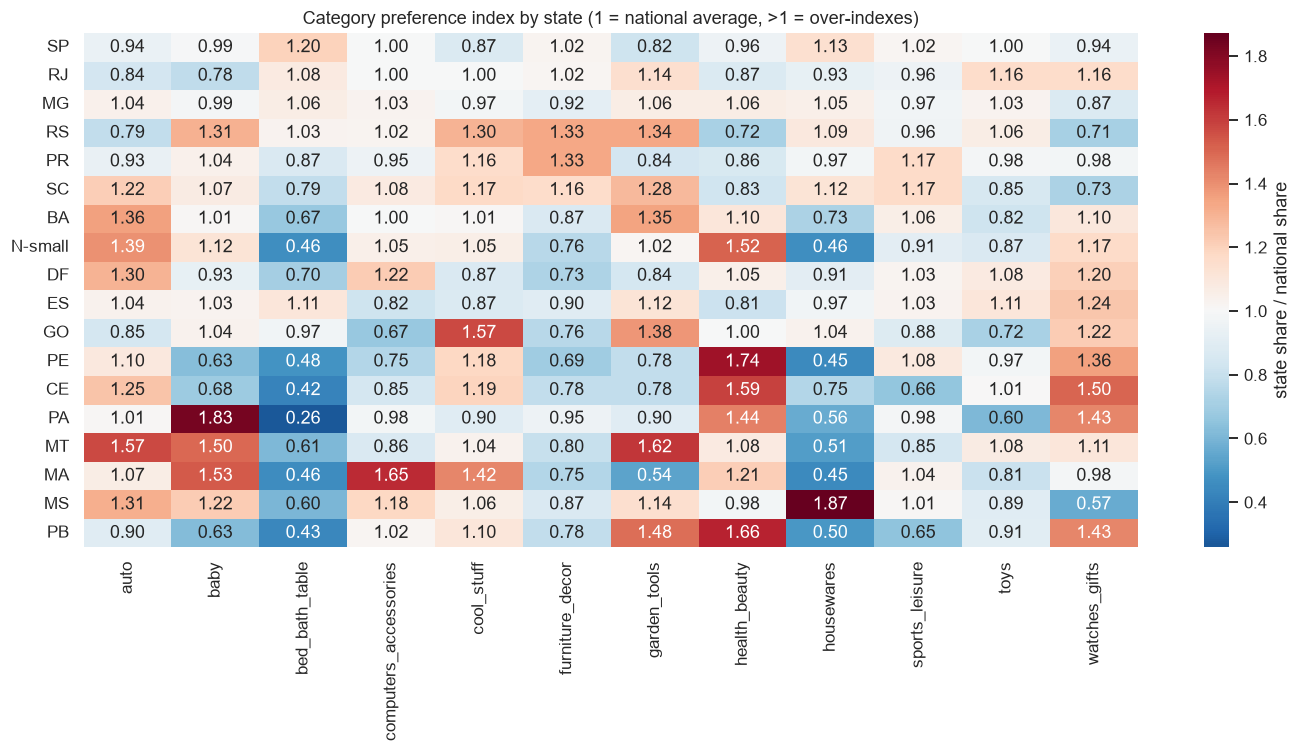

In [8]:
cat = consolidated.dropna(subset=["product_category_name_english"]).rename(
    columns={"product_category_name_english": "category"})
top_cats = cat.groupby("category").price.sum().nlargest(12).index
cat = cat[cat.category.isin(top_cats)].assign(
    state_grp=lambda d: d.customer_state.where(~d.customer_state.isin(SMALL), "N-small"))

mix = cat.pivot_table(index="state_grp", columns="category", values="price", aggfunc="sum", fill_value=0)
mix_share = mix.div(mix.sum(axis=1), axis=0)                      # share of the state's own GMV
national  = cat.groupby("category").price.sum().pipe(lambda s: s / s.sum())
rel = mix_share.div(national, axis=1)                             # ...relative to the national mix

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(rel.loc[grp.index], cmap="RdBu_r", center=1, annot=True, fmt=".2f",
            cbar_kws={"label": "state share / national share"}, ax=ax)
ax.set_title("Category preference index by state (1 = national average, >1 = over-indexes)")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Observation.** Category mix is broadly national with local tilts rather than distinct regional
baskets. The largest deviation is health & beauty in PB, which takes about two thirds more of that
state's top-12 spend than it does nationally (index ≈ 1.66). For forecasting this means category
mix is a modest state-level feature, not a source of separate per-state models.


## 5. Monthly sales by state

`00` Section 4 shows that the ends of the window are thin (ramp-up in late 2016, truncation in
September 2018). Low order counts could leave most states with zero or single-digit GMV, which is noise rather than a data point. So the
usable window is fixed here as **2017-01 to 2018-08**.


In [9]:
WINDOW = consolidated.year_month.between(pd.Period("2017-01", "M"), pd.Period("2018-08", "M"))
ts = consolidated[WINDOW].copy()
ts["state_grp"] = ts.customer_state.where(~ts.customer_state.isin(SMALL), "N-small")

print(f"Usable window 2017-01..2018-08: {ts.year_month.nunique()} months, "
      f"{len(ts):,} line items ({len(ts) / len(consolidated):.1%} of the table)")
print("-> at most ~19 supervised samples per series after a 1-month lag;")
print("-> < 2 yearly cycles, so yearly seasonality cannot be estimated, only flagged (Black Friday dummy).")

Usable window 2017-01..2018-08: 20 months, 112,279 line items (99.7% of the table)
-> at most ~19 supervised samples per series after a 1-month lag;
-> < 2 yearly cycles, so yearly seasonality cannot be estimated, only flagged (Black Friday dummy).


### 5.1 How stable is each state's top-5 category list?

A cheap baseline for "what will sell next month" is "what sold this month". Persistence is the share
of last month's top-5 categories that are still in the top 5 this month.


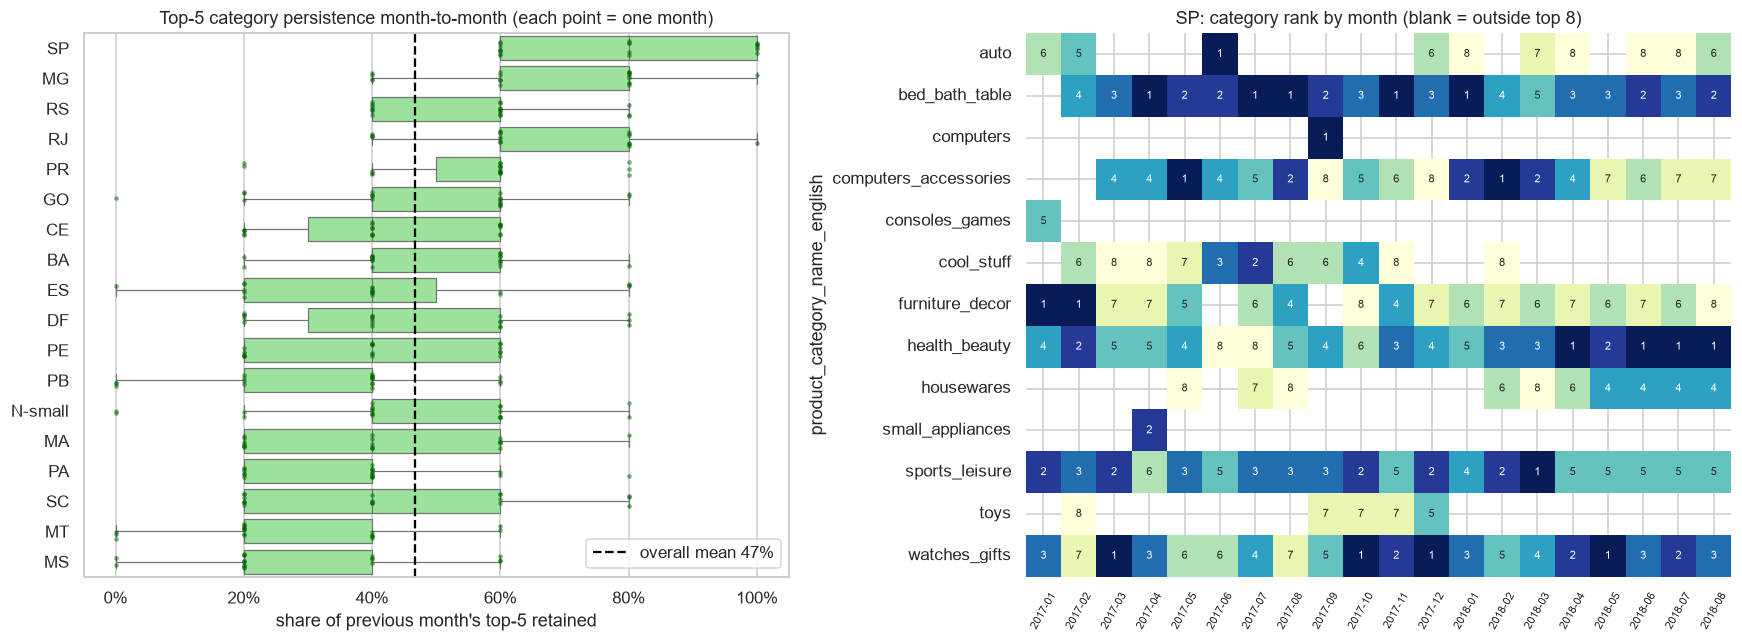

Persistence baseline: predicting 'same top-5 as last month' is already ~47% correct on average.


In [10]:
rank = (ts.groupby(["state_grp", "year_month", "product_category_name_english"]).price.sum()
          .groupby(level=[0, 1], group_keys=False).nlargest(5).reset_index())
top5 = rank.groupby(["state_grp", "year_month"]).product_category_name_english.apply(set)

def overlap(s):
    """Share of the previous month's top-5 retained this month, per state."""
    months = s.index.get_level_values("year_month")
    return pd.Series([len(s.iloc[i] & s.iloc[i - 1]) / 5 for i in range(1, len(s))], index=months[1:])

persist = top5.groupby(level=0, group_keys=True).apply(overlap)
pdf = persist.rename("persistence").reset_index()          # columns: state_grp, year_month, persistence
order_ = pdf.groupby("state_grp").persistence.median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=pdf, y="state_grp", x="persistence", order=order_, ax=axes[0],
            color="lightgreen", linewidth=0.8, showfliers=False)
sns.stripplot(data=pdf, y="state_grp", x="persistence", order=order_, ax=axes[0],
              color="darkgreen", size=3, alpha=0.5, jitter=0.25)
axes[0].axvline(persist.mean(), ls="--", color="black", label=f"overall mean {persist.mean():.0%}")
axes[0].set_title("Top-5 category persistence month-to-month (each point = one month)")
axes[0].set_xlabel("share of previous month's top-5 retained"); axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
axes[0].legend(loc="lower right")

# rank trajectory for the biggest market
sp = (ts[ts.state_grp == "SP"].groupby(["year_month", "product_category_name_english"]).price.sum()
      .groupby(level=0, group_keys=False).rank(ascending=False).unstack())
keep = sp.columns[(sp <= 5).any()]
sns.heatmap(sp[keep].T.where(sp[keep].T <= 8), cmap="YlGnBu_r", annot=True, fmt=".0f",
            cbar=False, ax=axes[1], annot_kws={"size": 7})
axes[1].set_title("SP: category rank by month (blank = outside top 8)"); axes[1].set_xlabel("")
axes[1].set_xticklabels([str(p) for p in sp.index], rotation=60, fontsize=7)
plt.tight_layout(); plt.show()

print(f"Persistence baseline: predicting 'same top-5 as last month' is already ~{persist.mean():.0%} correct on average.")

### 5.2 The forecast target: state × month GMV


360 state-month rows  |  log-corr(gmv, gmv incl. freight) = 0.9995


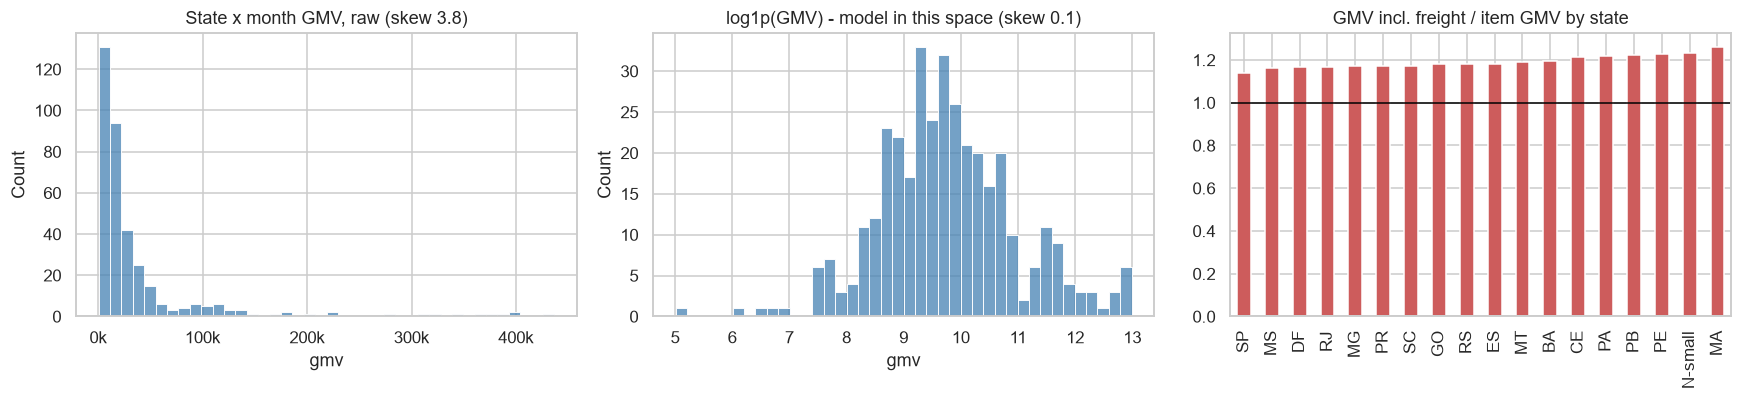

In [11]:
panel = (ts.groupby(["state_grp", "year_month"])
           .agg(gmv=("price", "sum"),                       # TARGET: item GMV (goods only)
                gmv_incl_freight=("item_revenue", "sum"),
                orders=("order_id", "nunique"),
                items=("order_item_id", "size"))
           .reset_index()
           .sort_values(["state_grp", "year_month"]))
print(f"{len(panel)} state-month rows  |  log-corr(gmv, gmv incl. freight) = "
      f"{np.corrcoef(np.log1p(panel.gmv), np.log1p(panel.gmv_incl_freight))[0, 1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
sns.histplot(panel.gmv, bins=40, ax=axes[0], color="steelblue")
axes[0].set_title(f"State x month GMV, raw (skew {panel.gmv.skew():.1f})")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e3:.0f}k"))
sns.histplot(np.log1p(panel.gmv), bins=40, ax=axes[1], color="steelblue")
axes[1].set_title(f"log1p(GMV) - model in this space (skew {np.log1p(panel.gmv).skew():.1f})")
ratio = panel.groupby("state_grp").apply(lambda g: g.gmv_incl_freight.sum() / g.gmv.sum()).sort_values()
ratio.plot.bar(ax=axes[2], color="indianred"); axes[2].axhline(1, color="black", lw=1)
axes[2].set_title("GMV incl. freight / item GMV by state"); axes[2].set_xlabel("")
plt.tight_layout(); plt.show()

**Observation.** Item GMV (goods only) is the right target and it should be modelled in log space.
GMV including freight is a near-deterministic state-level markup on it (log-correlation ≈ 0.9995), so
using it as the target would only leak the freight ratio from Section 3 into the model.


### 5.3 Do states move together?


Top 8 states = 84% of GMV


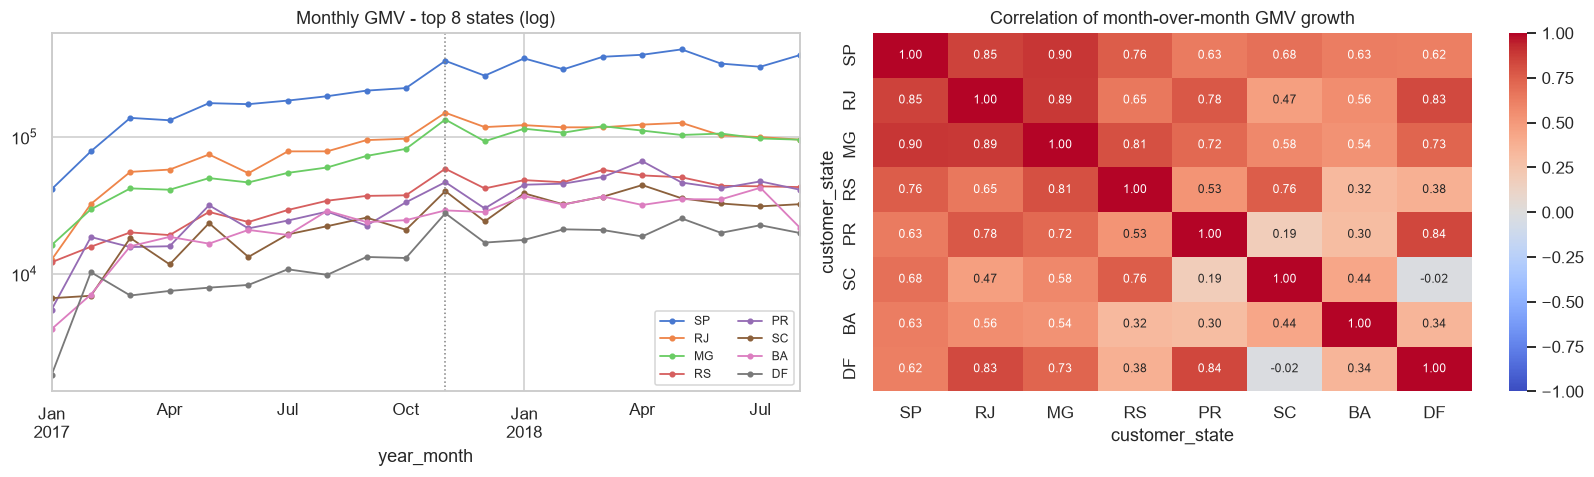

Lag-1 autocorrelation (level = trend persistence; growth = month-to-month momentum):
                level  growth
customer_state               
SP               0.87    0.01
RJ               0.84    0.30
MG               0.86   -0.05
RS               0.84   -0.44
PR               0.74   -0.37
SC               0.64   -0.58
BA               0.75    0.19
DF               0.69   -0.42


In [12]:
sm = ts.groupby(["customer_state", "year_month"]).price.sum().unstack().fillna(0)
top8 = sm.sum(axis=1).nlargest(8).index
print(f"Top 8 states = {sm.loc[top8].values.sum() / sm.values.sum():.0%} of GMV")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sm.loc[top8].T.pipe(lambda d: d.set_axis(d.index.to_timestamp())).plot(ax=axes[0], marker=".", lw=1.2)
axes[0].set_yscale("log"); axes[0].set_title("Monthly GMV - top 8 states (log)")
axes[0].axvline(pd.Timestamp("2017-11-01"), color="gray", ls=":", lw=1)
axes[0].legend(ncol=2, fontsize=8)

growth = (sm.loc[top8].T.pct_change()
            .replace([np.inf, -np.inf], np.nan).dropna())
sns.heatmap(growth.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
            ax=axes[1], annot_kws={"size": 8})
axes[1].set_title("Correlation of month-over-month GMV growth")
plt.tight_layout(); plt.show()

lag1 = pd.DataFrame({"level": sm.loc[top8].T.apply(lambda s: s.autocorr(1)),
                     "growth": growth.apply(lambda s: s.autocorr(1))}).round(2)
print("Lag-1 autocorrelation (level = trend persistence; growth = month-to-month momentum):")
print(lag1)

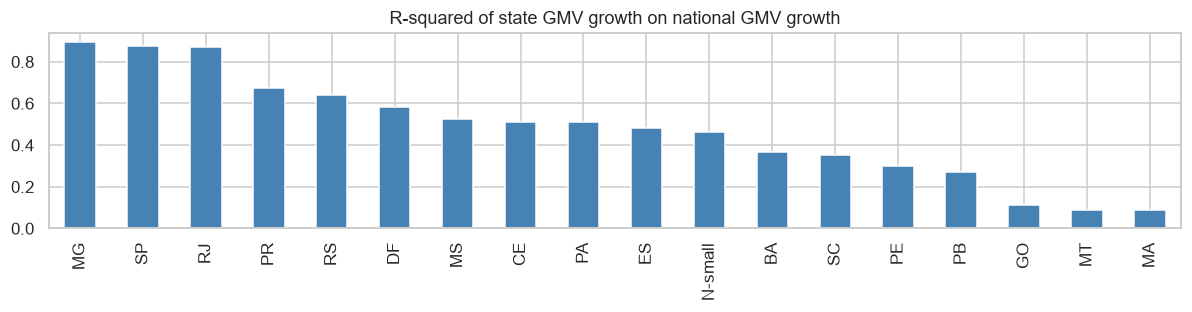

In [13]:
nat_growth = panel.groupby("year_month").gmv.sum().pct_change()
r2 = {}
for st, s in panel.pivot(index="year_month", columns="state_grp", values="gmv").pct_change().items():
    d = pd.concat([s, nat_growth], axis=1).dropna()
    r2[st] = np.corrcoef(d.iloc[:, 0], d.iloc[:, 1])[0, 1] ** 2

fig, ax = plt.subplots(figsize=(11, 3))
pd.Series(r2).sort_values(ascending=False).plot.bar(ax=ax, color="steelblue")
ax.set_title("R-squared of state GMV growth on national GMV growth"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

**Observation.** Growth co-movement is high among the big states, and their lag-1 autocorrelation in
levels is around 0.85. The dotted line is Black Friday 2017 — one observation, so it must enter as a
dummy, not be learned as seasonality (the same point `00` makes for the pooled series). The high
R² for the big states says a **pooled** model with a national trend and a state-specific level
(fixed effect) is the right architecture; the low R² for small states says their idiosyncratic
month-to-month noise is not forecastable, which is why they are merged.


## 6. Which signals predict next-month GMV within a state?

GMV is computed for each state per month (*$t_{month}^{state}$*). A set of candidate features (order count, new customers, AOV, late rate, review score, freight ratio, lagged GMV, growth and a time index) has been selected. Within-state Spearman correlation between *$t_{month}^{state}$* **features** and *following month* (*$t_{month+1}^{state}$*) **GMV**. \
Each feature is demeaned within its state so the correlation reflects month-to-month movement, not
the size of the state, so the correlation measures which signals lead a state's month-to-month movement rather than which states are large. \
Usable window selection is similar to Section 5 above. 


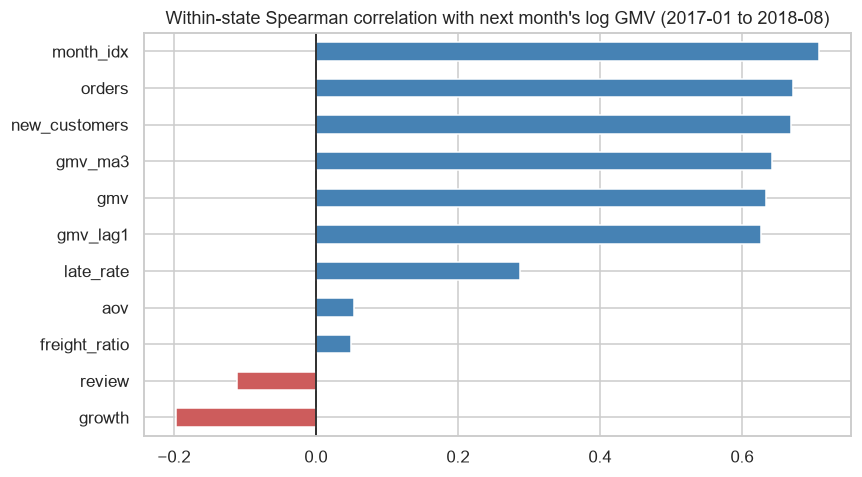

growth          -0.20
review          -0.11
freight_ratio    0.05
aov              0.05
late_rate        0.29
gmv_lag1         0.63
gmv              0.63
gmv_ma3          0.64
new_customers    0.67
orders           0.67
month_idx        0.71
Name: gmv_next, dtype: float64

In [14]:
ol = order_level[order_level.year_month.between(pd.Period("2017-01", "M"), pd.Period("2018-08", "M"))].copy()
first_seen = ol.groupby("customer_unique_id").year_month.min().rename("first_ym")
ol = ol.merge(first_seen, on="customer_unique_id")
ol["new_customer"] = ol.year_month == ol.first_ym

feat_panel = (ol.groupby(["state_grp", "year_month"])
                .agg(gmv=("basket_value", "sum"), orders=("order_id", "size"), aov=("payment_total", "mean"),
                     new_customers=("new_customer", "sum"), late_rate=("is_late", "mean"),
                     review=("review_score", "mean"), freight_ratio=("freight_ratio", "mean"))
                .reset_index().sort_values(["state_grp", "year_month"]))
g = feat_panel.groupby("state_grp")
feat_panel["gmv_next"]  = g.gmv.shift(-1)
feat_panel["gmv_lag1"]  = g.gmv.shift(1)
feat_panel["gmv_ma3"]   = g.gmv.transform(lambda s: s.rolling(3).mean())
feat_panel["growth"]    = g.gmv.pct_change()
feat_panel["month_idx"] = (feat_panel.year_month - pd.Period("2017-01", "M")).apply(lambda x: x.n)

FEATS = ["gmv", "gmv_lag1", "gmv_ma3", "orders", "new_customers", "aov", "growth",
         "late_rate", "review", "freight_ratio", "month_idx"]
d = feat_panel.dropna(subset=["gmv_next"]).copy()
for c in ["gmv", "gmv_next", "gmv_lag1", "gmv_ma3", "orders", "new_customers"]:
    d[c] = np.log1p(d[c])
within = d[FEATS + ["gmv_next"]].sub(d.groupby("state_grp")[FEATS + ["gmv_next"]].transform("mean"))
lead_corr = within.corr(method="spearman")["gmv_next"].drop("gmv_next").sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
lead_corr.plot.barh(ax=ax, color=np.where(lead_corr > 0, "steelblue", "indianred"))
ax.set_title("Within-state Spearman correlation with next month's log GMV (2017-01 to 2018-08)")
ax.axvline(0, color="black", lw=1)
plt.tight_layout(); plt.show()
lead_corr.round(3)

**Observation.** Next month's GMV is best explained by level and volume — the trend index, order
count, new-customer count and GMV with its lags all sit around rho ≈ 0.6–0.7. AOV, freight ratio and
review score add almost nothing, and last month's growth is slightly negative (mean reversion).


## 7. Key insights

**Regional consumer behaviour**
- Demand is as concentrated as supply: SP alone is roughly 42% of orders and 38% of GMV; SP + RJ + MG
  are two thirds of the market. Ten states have fewer than 500 orders and are pooled as `N-small`.
- Distance from the SP seller base is the organising variable for price and financing. Across states,
  median shipping distance correlates strongly with freight ratio and AOV (rho ≈ +0.8): freight rises
  from about 14% of basket in SP to 22–29% in the North/Northeast, and AOV from about R$ 140 to
  R$ 200–265, financed with more instalments.
- Higher AOV in distant states is not a bigger basket — items per order is 1.1–1.2 everywhere — but
  pricier items plus freight. Payment method mix, weekend share and repeat rate barely vary by state.
- Late-delivery rate is not a distance story (rho ≈ 0): RJ and BA are as bad as MA while remote MT sits
  low. Review scores follow the late rate, not distance — the same delivery-experience mechanism `00`
  identifies as the strongest relationship in the data.
- Category mix is broadly national with local tilts (e.g. health & beauty over-indexes ≈1.66× in PB).

**Implications for forecasting state × month GMV**
- The panel is small: 18 state groups × 20 usable months, at most ~19 supervised samples per series.
  Yearly seasonality cannot be estimated; Black Friday 2017 is a single observation and must be a dummy.
- Item GMV in log space is the right target — GMV including freight is a near-deterministic
  state-level markup (log-corr ≈ 0.9995) that would only leak the freight ratio into the model.
- Big states co-move with the national trend (lag-1 autocorrelation ≈ 0.85; high R² of state growth
  on national growth), small states are noise → a pooled model with a national trend and state fixed
  effects, small states merged.
- Within a state, next month's GMV is driven by level and volume (trend index, order count,
  new-customer count, GMV and its lags, rho ≈ 0.6–0.7); AOV, freight ratio and review score add almost
  nothing, and last month's growth mean-reverts.
- Naive baselines are strong and should be reported alongside any Phase 2 model: last month's top-5
  categories are already right about 46% of the time for the next month, and last month's GMV level
  is a hard-to-beat point forecast.

**Relative to the delivery problems in `02`–`03`.** Regional demand is viable but sits on a much
smaller effective sample, and its strongest within-state predictors are the target's own lags. `00`
reaches the same conclusion from the other direction: delivery is the spine of the dataset.
